# Bidirectional LSTM with GloVe Embeddings
**Dataset:** IMDB 50K Movie Reviews (HuggingFace)  
**Embeddings:** GloVe 100-dimensional pre-trained vectors  
**Goal:** Capture sequential and contextual patterns in reviews using a deep learning approach.

import re
import os
import json
import time
import zipfile
import requests
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # non-interactive backend for CI
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM, Dense, Dropout, GlobalMaxPooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_SEED  = 42
MAX_VOCAB    = 30_000
MAX_LEN      = 256
EMBED_DIM    = 100
BATCH_SIZE   = 128
EPOCHS       = 10

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print(f'TensorFlow version: {tf.__version__}')

In [1]:
import re
import os
import json
import time
import zipfile
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM, Dense, Dropout, GlobalMaxPooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
MAX_VOCAB = 30_000   # vocabulary size cap
MAX_LEN = 256      # max sequence length (tokens)
EMBED_DIM = 100      # GloVe dimension
BATCH_SIZE = 128
EPOCHS = 10

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print(f'TensorFlow version: {tf.__version__}')

I0000 00:00:1777281235.857159    2572 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777281235.899241    2572 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.21.0


I0000 00:00:1777281237.498386    2572 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 2. Load Dataset

In [2]:
dataset = load_dataset('imdb')

train_texts = dataset['train']['text']
train_labels = np.array(dataset['train']['label'])
test_texts = dataset['test']['text']
test_labels = np.array(dataset['test']['label'])

print(f'Train: {len(train_texts):,} | Test: {len(test_texts):,}')

Train: 25,000 | Test: 25,000


## 3. Text Preprocessing

In [3]:
def preprocess(text: str) -> str:
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)      # remove HTML
    text = re.sub(r'[^a-z\s]', ' ', text)     # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_clean = [preprocess(t) for t in train_texts]
test_clean = [preprocess(t) for t in test_texts]
print('Preprocessing done.')

Preprocessing done.


## 4. Tokenization & Padding

In [4]:
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(train_clean)

word_index = tokenizer.word_index
print(f'Unique tokens in corpus: {len(word_index):,}')
print(f'Vocabulary capped at   : {MAX_VOCAB:,}')

train_seq = tokenizer.texts_to_sequences(train_clean)
test_seq = tokenizer.texts_to_sequences(test_clean)

X_train = pad_sequences(train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test = pad_sequences(test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'\nX_train shape: {X_train.shape}')
print(f'X_test  shape: {X_test.shape}')

seq_lens = [len(s) for s in train_seq]
print(f'\nSequence length, Mean: {np.mean(seq_lens):.0f} | Max: {max(seq_lens)} | 95th pct: {np.percentile(seq_lens, 95):.0f}')

Unique tokens in corpus: 73,268
Vocabulary capped at   : 30,000



X_train shape: (25000, 256)
X_test  shape: (25000, 256)

Sequence length — Mean: 237 | Max: 2494 | 95th pct: 608


## 5. Load GloVe Embeddings

In [5]:
GLOVE_PATH = 'glove.6B.100d.txt'
GLOVE_URL = 'https://nlp.stanford.edu/data/glove.6B.zip'

if not os.path.exists(GLOVE_PATH):
    print('Downloading GloVe 6B 100d embeddings (~822 MB)...')
    r = requests.get(GLOVE_URL, stream=True)
    with open('glove.6B.zip', 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print('Extracting...')
    with zipfile.ZipFile('glove.6B.zip', 'r') as z:
        z.extract('glove.6B.100d.txt')
    os.remove('glove.6B.zip')
    print('GloVe ready.')
else:
    print('GloVe file already exists, skipping download.')

glove_embeddings = {}
with open(GLOVE_PATH, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        glove_embeddings[word] = vector

print(f'Loaded {len(glove_embeddings):,} GloVe vectors.')

Extracting...


GloVe ready.


Loaded 400,000 GloVe vectors.


In [6]:
embedding_matrix = np.zeros((MAX_VOCAB, EMBED_DIM))
hits, misses = 0, 0

for word, idx in word_index.items():
    if idx >= MAX_VOCAB:
        continue
    vec = glove_embeddings.get(word)
    if vec is not None:
        embedding_matrix[idx] = vec
        hits += 1
    else:
        misses += 1

coverage = hits / (hits + misses) * 100
print(f'Embedding coverage: {hits:,} hits / {misses:,} misses ({coverage:.1f}%)')

Embedding coverage: 29,384 hits / 615 misses (97.9%)


## 6. Build Bidirectional LSTM Model

In [7]:
def build_bilstm(vocab_size, embed_dim, embed_matrix, max_len):
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim,
            weights=[embed_matrix],
            input_length=max_len,
            trainable=False,
            name='glove_embedding'
        ),
        Bidirectional(LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)),
        Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.2)),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_bilstm(MAX_VOCAB, EMBED_DIM, embedding_matrix, MAX_LEN)
model.summary()

E0000 00:00:1777281417.205386    2572 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ ?                      │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000,000 (11.44 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,000,000 (11.44 MB)

## 7. Train Model

In [8]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

t0 = time.time()
history = model.fit(
    X_train, train_labels,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)
train_time = time.time() - t0
print(f'\nTraining time: {train_time:.1f}s')

Epoch 1/10


  1/176 ━━━━━━━━━━━━━━━━━━━━ 25:24 9s/step - accuracy: 0.4922 - loss: 0.7018

  2/176 ━━━━━━━━━━━━━━━━━━━━ 3:16 1s/step - accuracy: 0.4629 - loss: 0.7069 

  3/176 ━━━━━━━━━━━━━━━━━━━━ 3:16 1s/step - accuracy: 0.4674 - loss: 0.7062

  4/176 ━━━━━━━━━━━━━━━━━━━━ 3:15 1s/step - accuracy: 0.4751 - loss: 0.7046

...

176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8355 - loss: 0.3793

176/176 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.8354 - loss: 0.3791 - val_accuracy: 0.8288 - val_loss: 0.4058 - learning_rate: 5.0000e-04


Epoch 9: early stopping


Restoring model weights from the end of the best epoch: 6.



Training time: 1806.4s


## 8. Training Curves

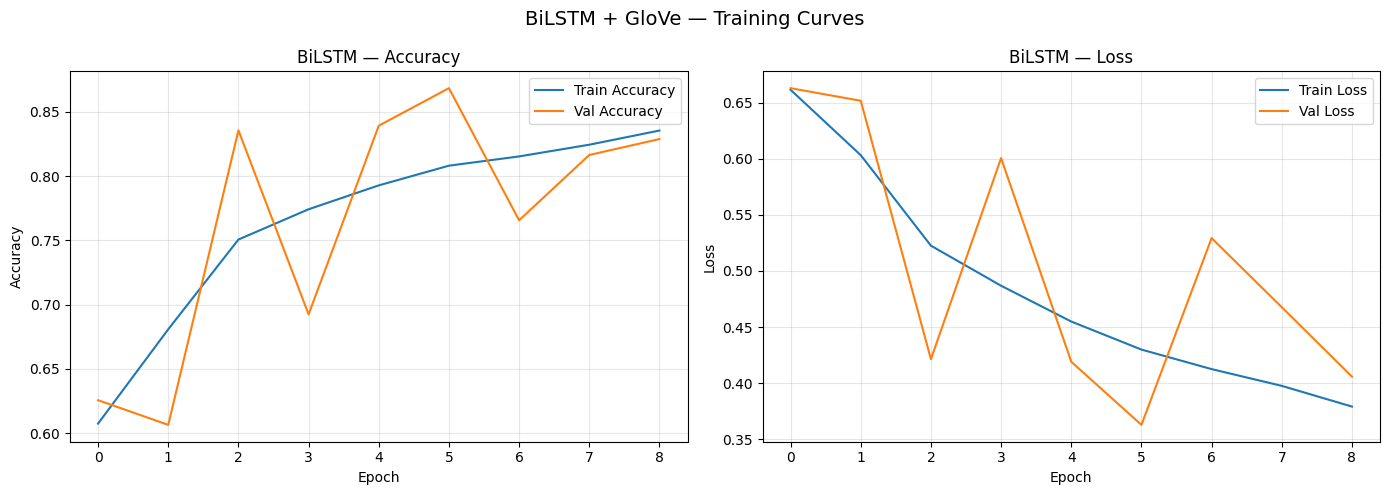

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('BiLSTM, Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('BiLSTM, Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('BiLSTM + GloVe, Training Curves', fontsize=14)
plt.tight_layout()
plt.savefig('results/lstm_training_curves.png', dpi=150)
plt.show()

## 9. Evaluation

In [10]:
t0 = time.time()
prob_preds = model.predict(X_test, batch_size=256, verbose=0).squeeze()
latency_ms = (time.time() - t0) / len(test_labels) * 1000

preds = (prob_preds >= 0.5).astype(int)

acc = accuracy_score(test_labels, preds)
f1 = f1_score(test_labels, preds, average='binary')

print(f'Accuracy         : {acc:.4f}')
print(f'F1 Score         : {f1:.4f}')
print(f'Latency/sample   : {latency_ms:.4f} ms')
print()
print(classification_report(test_labels, preds, target_names=['Negative', 'Positive']))

Accuracy         : 0.8248
F1 Score         : 0.8329
Latency/sample   : 1.9745 ms

              precision    recall  f1-score   support

    Negative       0.86      0.78      0.82     12500
    Positive       0.80      0.87      0.83     12500

    accuracy                           0.82     25000
   macro avg       0.83      0.82      0.82     25000
weighted avg       0.83      0.82      0.82     25000



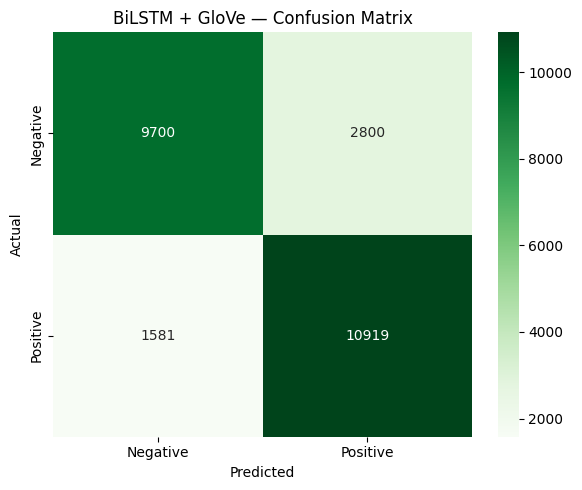

In [11]:
cm = confusion_matrix(test_labels, preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('BiLSTM + GloVe, Confusion Matrix')
plt.tight_layout()
plt.savefig('results/lstm_confusion_matrix.png', dpi=150)
plt.show()

## 10. Save Metrics

In [12]:
metrics = {
    'model'       : 'Bidirectional LSTM + GloVe 100d',
    'accuracy'    : round(acc, 4),
    'f1_score'    : round(f1, 4),
    'latency_ms'  : round(latency_ms, 4),
    'train_time_s': round(train_time, 2),
    'epochs_ran'  : len(history.history['loss'])
}

with open('results/lstm_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Metrics saved to results/lstm_metrics.json')
print(json.dumps(metrics, indent=2))

Metrics saved to results/lstm_metrics.json
{
  "model": "Bidirectional LSTM + GloVe 100d",
  "accuracy": 0.8248,
  "f1_score": 0.8329,
  "latency_ms": 1.9745,
  "train_time_s": 1806.41,
  "epochs_ran": 9
}
